<b>Setup</b>

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

<b>Import der Daten</b>


In [36]:
df = pd.read_csv("../data/ai_student_impact_dataset.csv")

df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


<b>Der Datensatz im Überblick:</b>

Zu sehen sind die jeweiligen Spalten des Datensatzes sowie die Anzahl der Einträge und dem jeweilig verwendeten Datentyp.


In [37]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

(50000, 16)

<b>Leere Einträge finden und entfernen:</b>

Entfernt zunächst alle leeren Zellen, final wird eine Liste ausgegeben die die jeweilige Anzahl an entfernten Zellen in der Spalte enthält.


In [38]:
df.isnull().sum()
df_clean = df.dropna()

df_clean.isnull().sum()

Student_ID                    0
Major_Category                0
Year_of_Study                 0
Pre_Semester_GPA              0
Weekly_GenAI_Hours            0
Primary_Use_Case              0
Prompt_Engineering_Skill      0
Tool_Diversity                0
Paid_Subscription             0
Traditional_Study_Hours       0
Perceived_AI_Dependency       0
Institutional_Policy          0
Anxiety_Level_During_Exams    0
Post_Semester_GPA             0
Skill_Retention_Score         0
Burnout_Risk_Level            0
dtype: int64

<b>Kategorische Spalten finden (Spalten ohne numerische Werte):</b>

Diese lassen sich am Datentyp(object) erkennen, anhand dessen sie auch gefiltert werden können


In [39]:
categorical_columns = df_clean.select_dtypes(include=["object"]).columns

print("Kategorische Spalten:", categorical_columns)

Kategorische Spalten: Index(['Major_Category', 'Year_of_Study', 'Primary_Use_Case',
       'Prompt_Engineering_Skill', 'Institutional_Policy',
       'Burnout_Risk_Level'],
      dtype='object')


<b>One-Hot.Encoding durchführen:</b>

Führt zunächst das One-Hot.Encoding durch, visualisiert danach die entstandene Tabelle mit den neuen Spalten.<br>
drop_first = erste Möglickeit für Dummy Entries wird gedroppt/als Standard gesetzt, d.h gibt es k-1 neue Spalten wenn k für die Möglichkeiten steht, die eine Kategorische Variable annehmen kann.


In [40]:
df_encoded = pd.get_dummies(df_clean, columns=categorical_columns, drop_first=True)

df_encoded.head()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,...,Primary_Use_Case_Debugging/Troubleshooting,Primary_Use_Case_Direct_Answer_Generation,Primary_Use_Case_Ideation,Primary_Use_Case_Summarizing_Reading,Prompt_Engineering_Skill_Beginner,Prompt_Engineering_Skill_Intermediate,Institutional_Policy_Allowed_With_Citation,Institutional_Policy_Strict_Ban,Burnout_Risk_Level_Low,Burnout_Risk_Level_Medium
0,100001,2.418,23.31,1,True,8.13,5,6,2.393,86.44,...,False,False,False,False,True,False,True,False,False,False
1,100002,3.821,1.12,5,False,16.65,3,9,3.696,69.39,...,False,False,True,False,False,False,True,False,True,False
2,100003,3.398,21.26,2,False,10.35,5,9,3.499,73.93,...,False,False,False,True,True,False,False,True,False,True
3,100004,3.789,1.82,4,False,15.23,2,2,4.000,63.58,...,False,False,False,False,False,True,True,False,False,True
4,100005,3.635,9.29,4,False,12.55,4,4,3.798,100.00,...,True,False,False,False,False,False,True,False,False,True


<b>Pairplot erstellen:</b>

bei der Erstellung werden nur die ursrpünglich numerischen Spalten verwendet, da durch das One-Hot-Encoding viele Spalten entstehen die das pairplot unübersichtlicher machen. Konkret werden die Spalten angezeigt, welche ursprünglich int und float Werte enthalten.


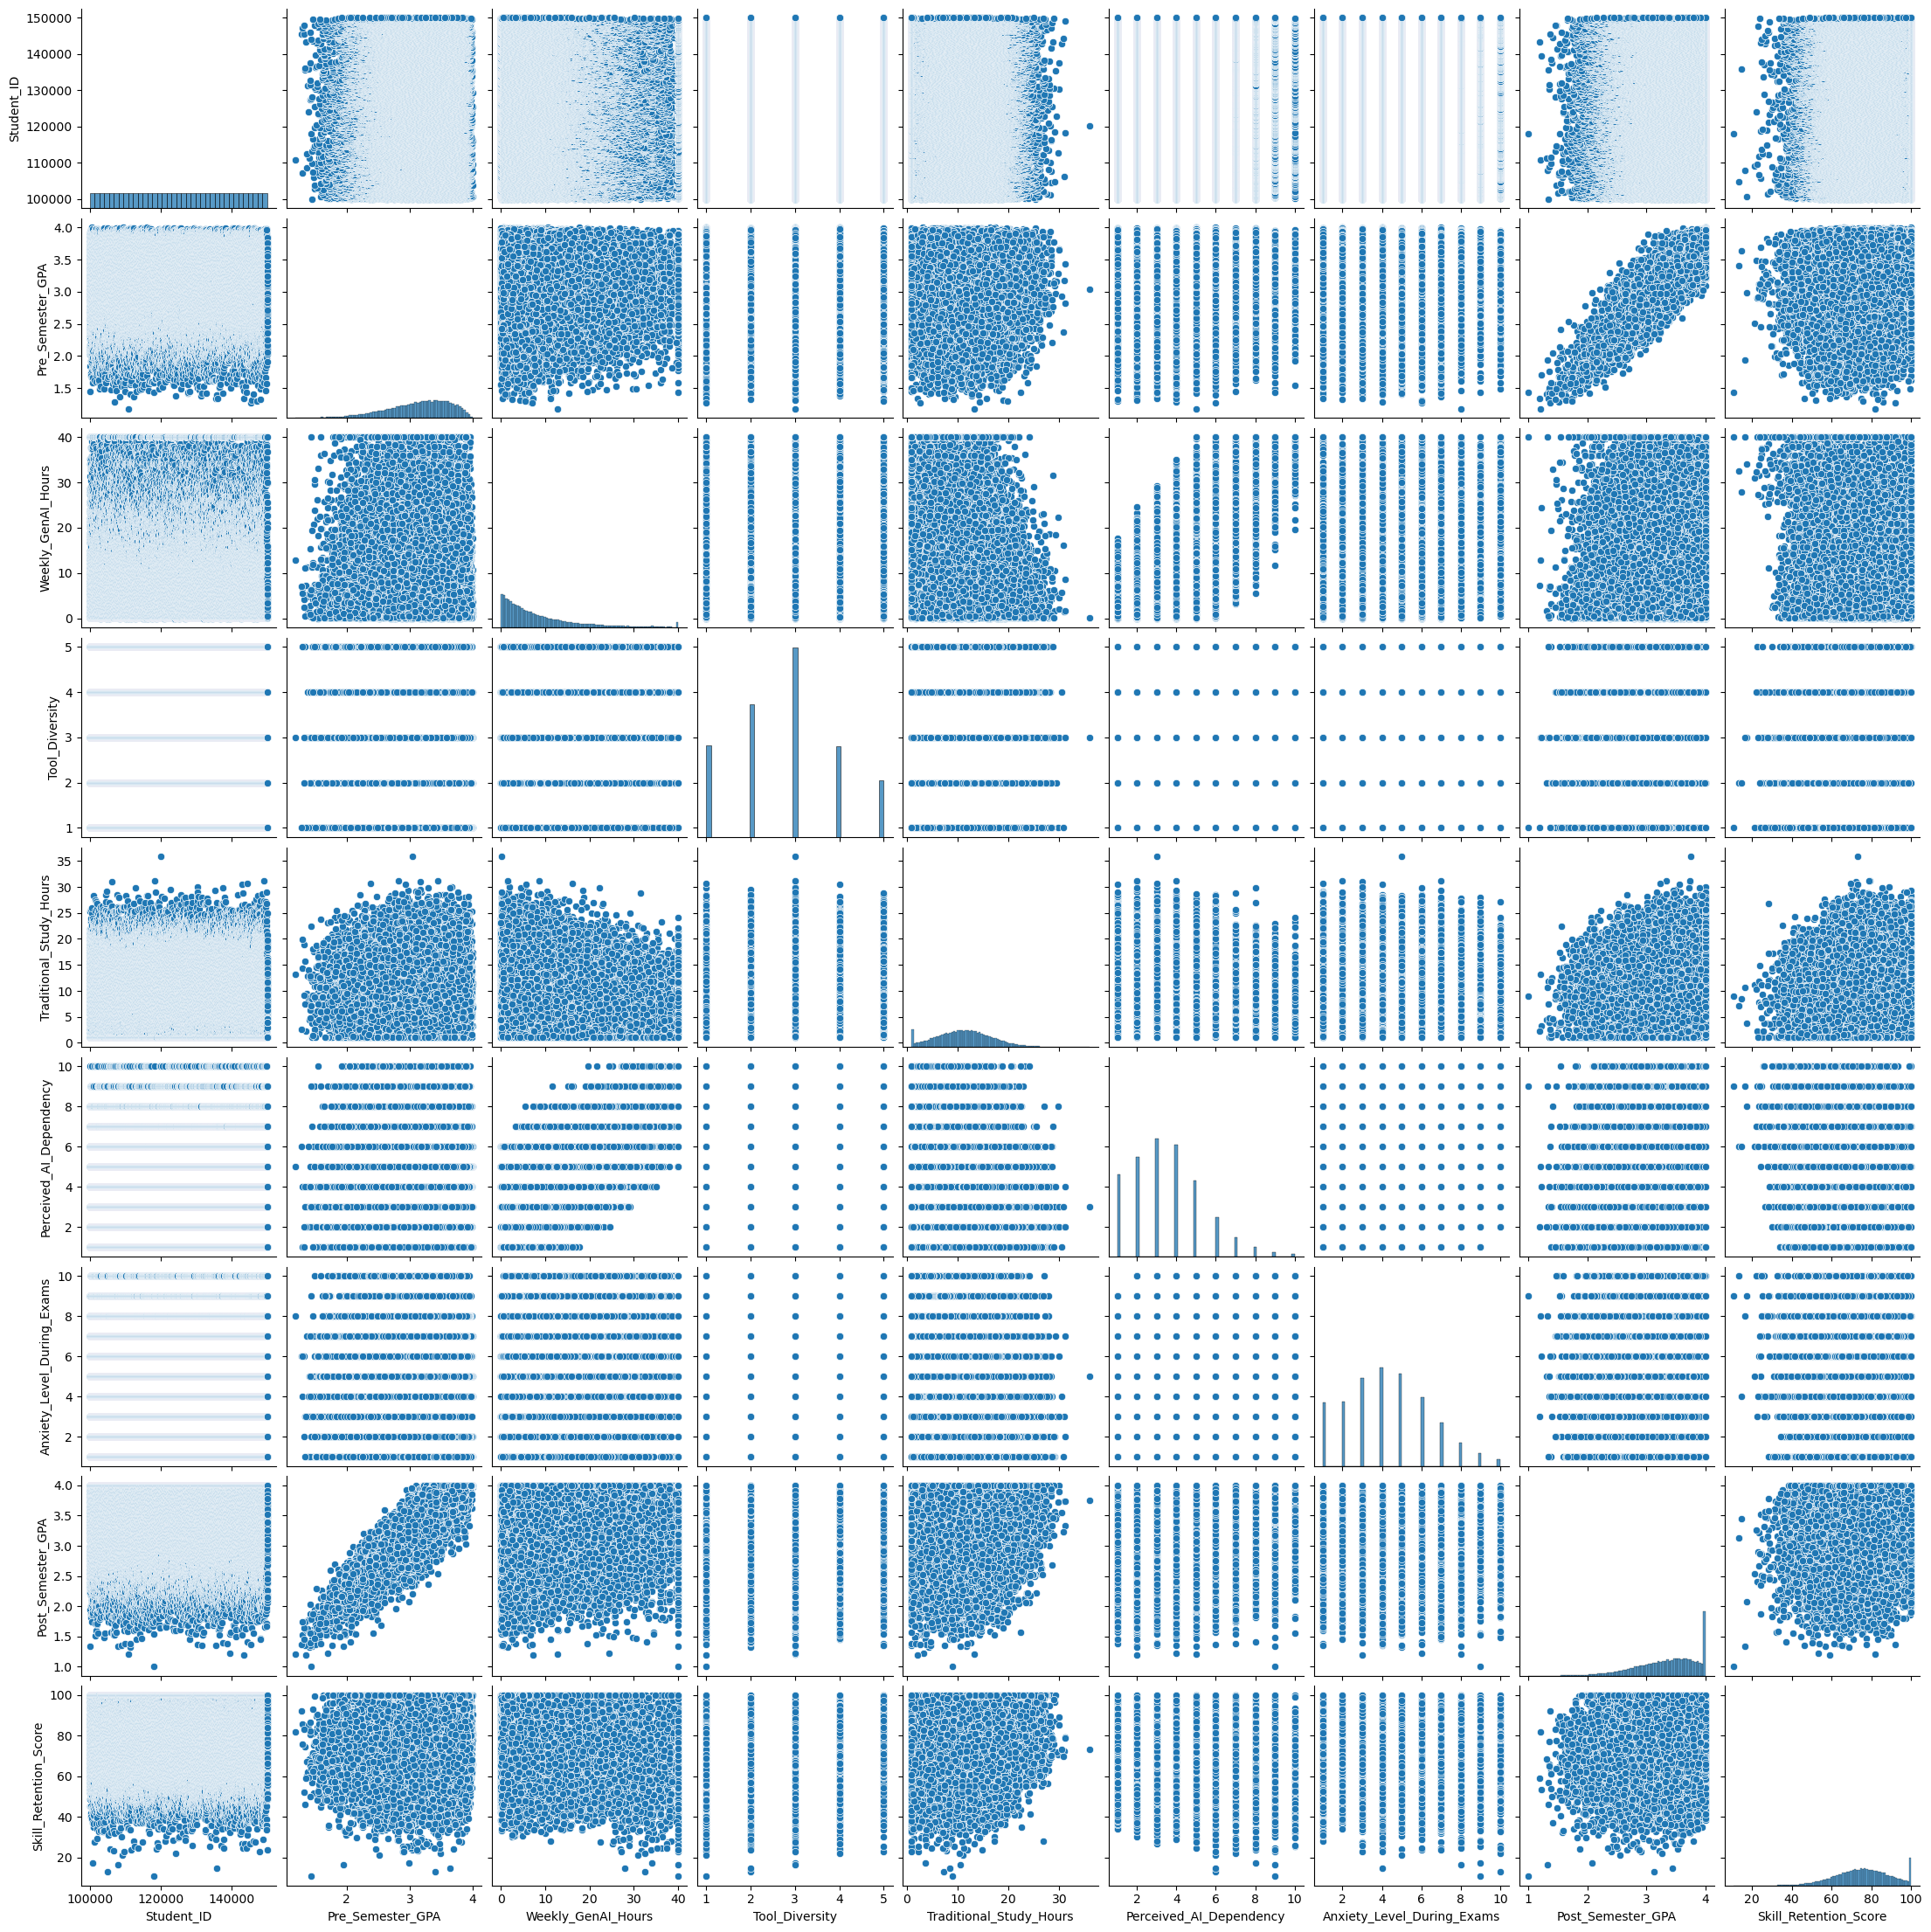

In [41]:
numeric_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

sns.pairplot(df_clean[numeric_columns])
plt.show()

<b>Interpretation Pairplot:</b>
<br>
<table>
  <thead>
    <tr>
      <th>Variable</th>
      <th>Einfluss auf Post_Semester_GPA (Abschlussnote)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Pre_Semester_GPA</td>
      <td>Stark positiv</td>
    </tr>
    <tr>
      <td>Skill_Retention_Score</td>
      <td>Stark positiv (oder die Folge guter Noten)</td>
    </tr>
    <tr>
      <td>Traditional_Study_Hours</td>
      <td>Schwach positiv</td>
    </tr>
    <tr>
      <td>Weekly_GenAI_Hours</td>
      <td>Kein klarer linearer Effekt</td>
    </tr>
    <tr>
      <td>Anxiety / AI_Dependency</td>
      <td>Kein klarer Effekt sichtbar</td>
    </tr>
  </tbody>
</table>


Begründungen ausformulieren

<b>Regression oder Klassifikation:</b>
<br>
<br>
Output Variable :
Post_Semester_GPA (Die Note nach dem Semester, Wertebereich = 1.0–4.0, kontinuierliche Variable)
<br>
<br>
Input Variablen:
<table>
  <thead>
    <tr>
      <th>Variable</th>
      <th>Datentyp</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Pre_Semester_GPA</td>
      <td>Kontinuierlich</td>
    </tr>
    <tr>
      <td>Weekly_GenAI_Hours</td>
      <td>Kontinuierlich</td>
    </tr>
    <tr>
      <td>Tool_Diversity</td>
      <td>Diskret (1–5)</td>
    </tr>
    <tr>
      <td>Traditional_Study_Hours</td>
      <td>Kontinuierlich</td>
    </tr>
    <tr>
      <td>Perceived_AI_Dependency</td>
      <td>Ordinal (1–10)</td>
    </tr>
    <tr>
      <td>Anxiety_Level_During_Exams</td>
      <td>Ordinal (1–10)</td>
    </tr>
    <tr>
      <td>Skill_Retention_Score</td>
      <td>Kontinuierlich</td>
    </tr>
    <tr>
      <td>One-Hot-Encoded Variablen</td>
      <td>Binär (0/1)</td>
    </tr>
  </tbody>
</table>


<b>Empfehlung Regression:</b>

1. Der GPA ist eine kontinuierliche Variable mit vielen möglichen Werten (1.0, 1.1, 1.2, ... 4.0). Regression modelliert genau solche Zusammenhänge.
2. Informationsverlust bei Klassifikation: Würde man den GPA in Klassen einteilen, ginge die Abstufung verloren. Ein Unterschied zwischen 2.9 und 3.1 wäre dann irrelevant, obwohl er existiert.

Für Klassifikation müsste die Frage angepast werden, von lässt sich die Note anhand von Paramter x + y + z vorhersagen zu besteht der Student (Klassifikation in Ja oder Nein) anhand von Parameter x + y + z


<b>Fragestellung für Prediction und Inference</b>
<br>
<br>
Inference Frage : Welchen Einfluss hat die wöchentliche Nutzung von GenAI-Tools auf die Semesternote, wenn man für traditionelle Lernzeit, bisherige Leistungen und andere Faktoren(Skill Retention, Anxiet Level) kontrolliert?

Prediction Frage: Wie gut lässt sich der Semester-GPA eines Studierenden anhand seiner Lerngewohnheiten, KI-Nutzung und bisherigen Leistungen vorhersagen?




<b>Training und Fitting für einen Regression Tree:</b>
<br>
<br>
1: Aufteilung des Datensatzes in Trainings und Testdaten (80/20 Split).<br>
2: Suche nach optimalen Parametern (im Fokus : max_depth, min_sample_leaf, ccp_alpha).<br>
3: Erstellung eines Baumes mit optimalen Parametern.<br>
4: Overfitting Check.<br>
5: Visualisierung des Overfitting.<br>
6: Erzeugung einer Vorhersage.<br>
7: Evaluation des Baumes nach R2-Score und Feature Importance.<br>
8: Visualisierun des Baumes.<br>

<b>Aufteilung in Training & Testdaten(1) + Suche nach Parametern(2)</b>

In [52]:
target = "Post_Semester_GPA"

X = df_encoded.drop(columns=[target])
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [10, 50, 100, 200],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1]
}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,                
    scoring='r2',
    return_train_score=True
)
grid_search.fit(X_train, y_train)
print("Beste Parameter:", grid_search.best_params_)
print("Bester CV R²:", grid_search.best_score_)

Beste Parameter: {'ccp_alpha': 0.0, 'max_depth': 10, 'min_samples_leaf': 50}
Bester CV R²: 0.8810063568999118


<b>Erstellung des Trees mit optimalen Parametern(3)</b>

In [53]:
tree = DecisionTreeRegressor(
    max_depth=10,
    random_state=42,
    min_samples_leaf = 50,
    min_samples_split = 100,
    ccp_alpha=0.0
)

tree.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,100
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


<b>Overfitting-Check(4)</b>
<br>
<br>
Um Overfitting festzustellen werden die Ergebnisse der Test und Trainingsdaten Prediction mit dem R2 Score gegeneinander verglichen.


In [55]:
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

print("Overfitting-Check")
print(f"R² Training: {r2_score(y_train, y_train_pred):.4f}")
print(f"R² Test:     {r2_score(y_test, y_test_pred):.4f}")
print(f"Differenz:   {r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred):.4f}")
print()
print(f"RMSE Training: {np.sqrt(mean_squared_error(y_train, y_train_pred)):.4f}")
print(f"RMSE Test:     {np.sqrt(mean_squared_error(y_test, y_test_pred)):.4f}")


Overfitting-Check
R² Training: 0.8972
R² Test:     0.8822
Differenz:   0.0150

RMSE Training: 0.1593
RMSE Test:     0.1686


<b>Overfitting Visualisierung(5)</b>

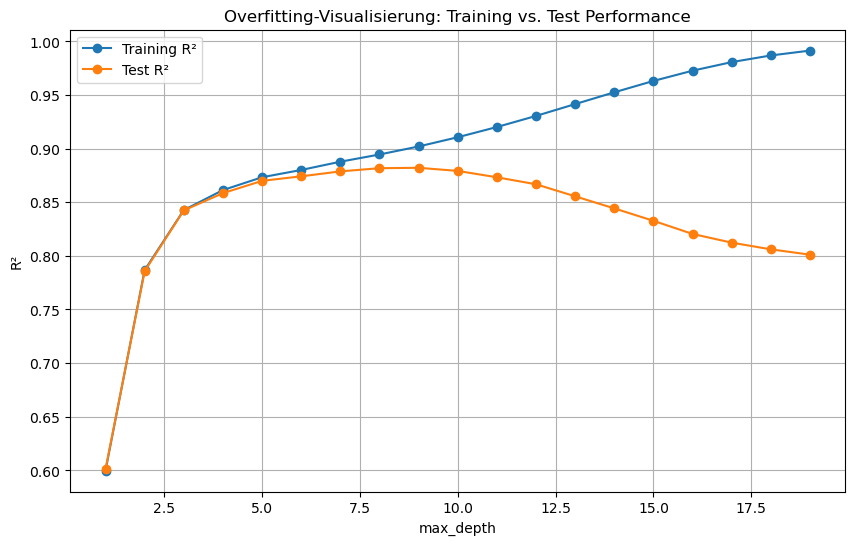

In [56]:
train_scores = []
test_scores = []
depths = range(1, 20)
for depth in depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(r2_score(y_train, model.predict(X_train)))
    test_scores.append(r2_score(y_test, model.predict(X_test)))
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, label='Training R²', marker='o')
plt.plot(depths, test_scores, label='Test R²', marker='o')
plt.xlabel('max_depth')
plt.ylabel('R²')
plt.title('Overfitting-Visualisierung: Training vs. Test Performance')
plt.legend()
plt.grid(True)
plt.show()

<b>Erzeugung einer Vorhersage(6)</b>

In [57]:
y_pred = tree.predict(X_test)

print("Prediction :", y_pred)

Prediction : [2.31888732 3.10868493 3.0641     ... 3.38519118 3.04371429 3.19601429]


<b>Evaluation des Baums nach R2 Score und Feature Importance(7)</b>
<br>
<br>
Warum R2-Score als Evaluationsmetrik:<br>
Um mit Recall, Precision oder F1 Score zu evaluieren, müsste die Zielgröße angepasst werden, da diese Metriken üblicherweise für Klassifikation genutzt werden nicht Regression.

In [58]:
r2 = r2_score(y_test, y_pred)

print("R²:", r2)


importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

R²: 0.8822394706500163


,Feature,Importance
1,Pre_Semester_GPA,0.961389
5,Traditional_Study_Hours,0.023713
8,Skill_Retention_Score,0.003128
2,Weekly_GenAI_Hours,0.003105
17,Primary_Use_Case_Debugging/Troubleshooting,0.002014
18,Primary_Use_Case_Direct_Answer_Generation,0.001915
15,Year_of_Study_Senior,0.001105
22,Prompt_Engineering_Skill_Intermediate,0.000941
13,Year_of_Study_Graduate,0.000670
21,Prompt_Engineering_Skill_Beginner,0.000516


<b>Evaluation der Ergebnisse</b>
<br>
<br>
To be done:<br>
Die wichtigsten Entscheidungsregeln des Modells<br>
Welche Parameter hatten den größten Einfluss auf die Modellqualität?<br>
Wie konnte Overfitting reduziert werden?<br>
Interpretieren Sie die Ergebnisse der Evaluation: Mit welchen Einstellungen konnten Sie die besten Ergebnisse erreichen?


<b>Baum visualisieren (Mehr als fünf Ebenen erzeugen hohe Wartezeiten (Parameter max_depth))(8)</b>

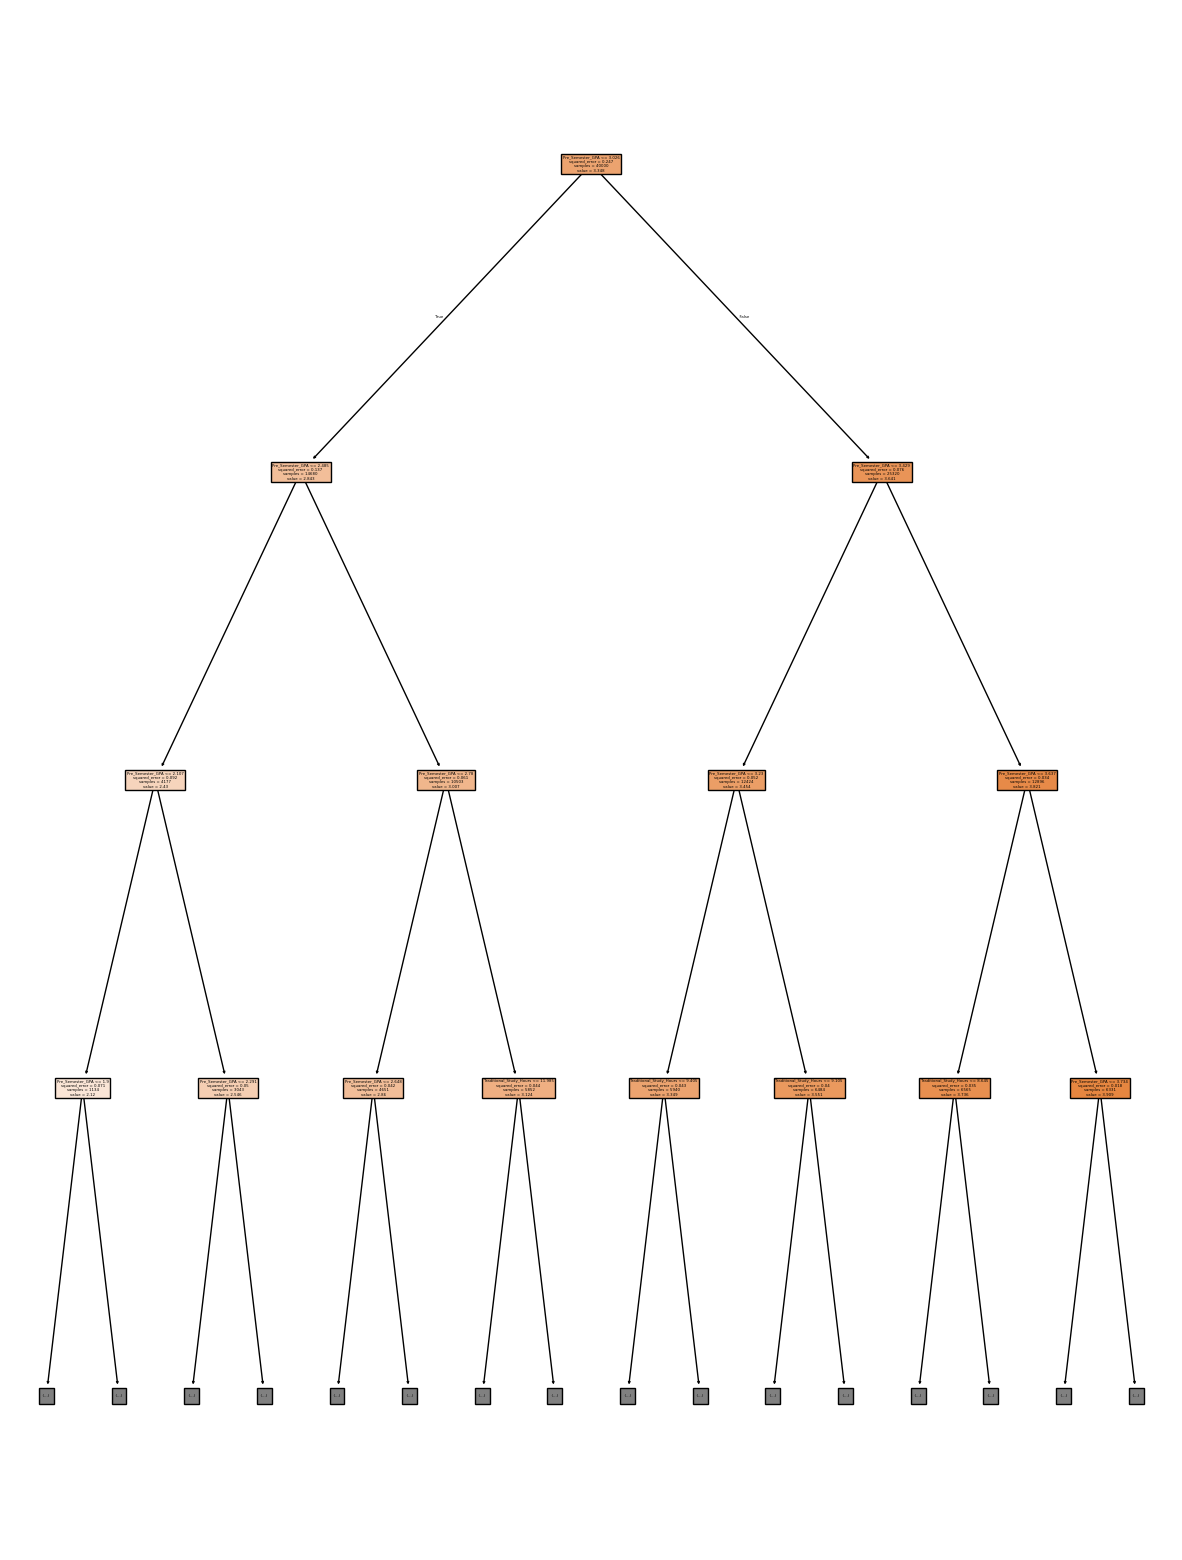

In [59]:
plt.figure(figsize=(15,20))

plot_tree(
    tree,
    max_depth=3,
    filled=True,
    feature_names=X.columns
)

plt.show()